# Adaptive PEJ Python Simulation Demo

This notebook demonstrates the lightweight Python simulation framework that replaces a MATLAB/Simulink-style block diagram with SciPy ODE integration.

In [15]:
from pathlib import Path
import sys

repo = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo))

import numpy as np
from simulation.controller import FeedforwardTorqueController
from simulation.dynamics import JointSimulationConfig, simulate_joint
from simulation.energy import compare_energy
from simulation.plots import plot_adaptive_state, plot_energy_comparison, plot_joint_state, plot_torques_and_power
from simulation.spring_models import AdaptiveBlendModel, ActuatorTunedModel, FixedSpringModel
from simulation.terrain import StepTerrainSchedule

## Configure a mixed-terrain joint torque case

In [16]:
config = JointSimulationConfig(
    inertia=0.08,
    damping=0.02,
    t_span=(0.0, 6.0),
    dt=0.01,
    initial_theta=0.12,
)
terrain = StepTerrainSchedule(switch_time=3.0, q_before=0.0, q_after=1.0)

def required_torque(t):
    base = 0.7 * np.sin(2.0 * np.pi * 1.2 * t)
    rough = 0.35 * np.sin(2.0 * np.pi * 4.0 * t + 0.3) if t >= terrain.switch_time else 0.0
    return base + rough

controller = FeedforwardTorqueController(required_torque)

## Step 1: fixed spring simulation

In [17]:
no_spring = simulate_joint(
    spring_model=FixedSpringModel(stiffness=0.0),
    controller=controller,
    q_input=terrain.q,
    config=config,
)
fixed_soft = simulate_joint(
    spring_model=FixedSpringModel(stiffness=3.0),
    controller=controller,
    q_input=terrain.q,
    config=config,
)

## Step 2: adaptive blended spring simulation

In [18]:
blend = simulate_joint(
    spring_model=AdaptiveBlendModel(
        flat_profile=lambda theta: 3.0 * theta,
        rough_profile=lambda theta: 7.0 * theta,
    ),
    controller=controller,
    q_input=terrain.q,
    config=config,
)

## Step 3: actuator-tuned spring simulation

In [19]:
actuator_tuned = simulate_joint(
    spring_model=ActuatorTunedModel(
        k_soft=3.0,
        k_stiff=7.0,
        phi_min=-0.35,
        phi_max=0.35,
        actuator_time_constant=0.12,
    ),
    controller=controller,
    q_input=terrain.q,
    config=config,
)

## Compare results

In [20]:
results = {
    "no_spring": no_spring,
    "fixed_soft": fixed_soft,
    "adaptive_blend": blend,
    "actuator_tuned": actuator_tuned,
}
energy = compare_energy(results)
for name, summary in energy.items():
    print(f"{name:16s} avg_power={summary.average_motor_power:.4f} W offload={summary.offload_percentage:.2f}%")

no_spring        avg_power=0.1904 W offload=0.00%
fixed_soft       avg_power=1.1273 W offload=-492.06%
adaptive_blend   avg_power=2.4006 W offload=-1160.83%
actuator_tuned   avg_power=2.3873 W offload=-1153.82%


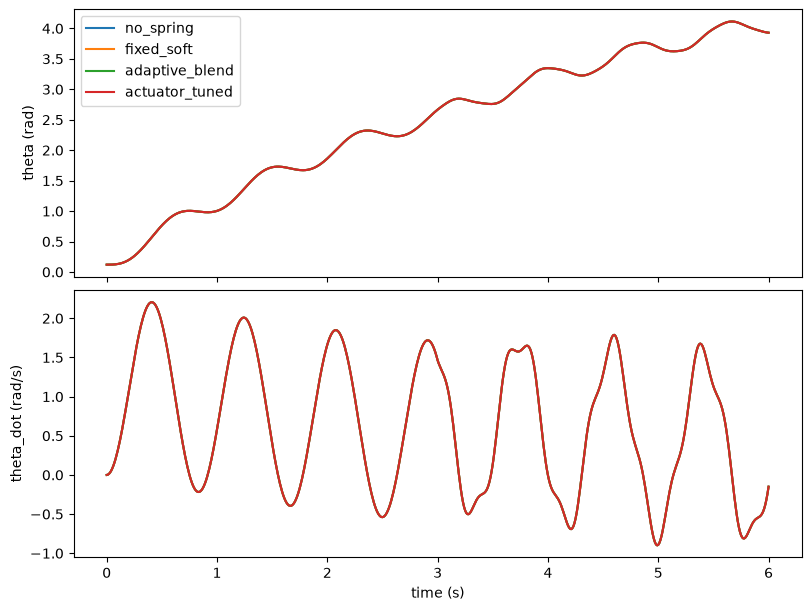

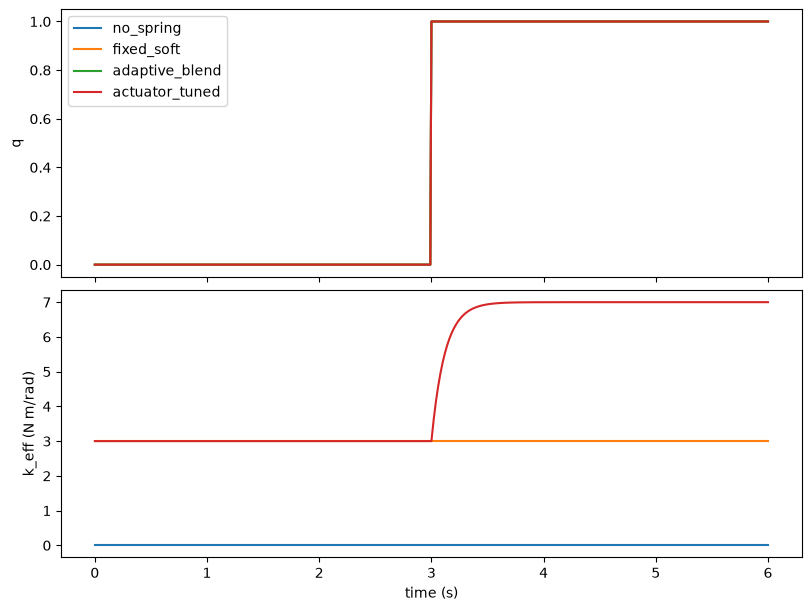

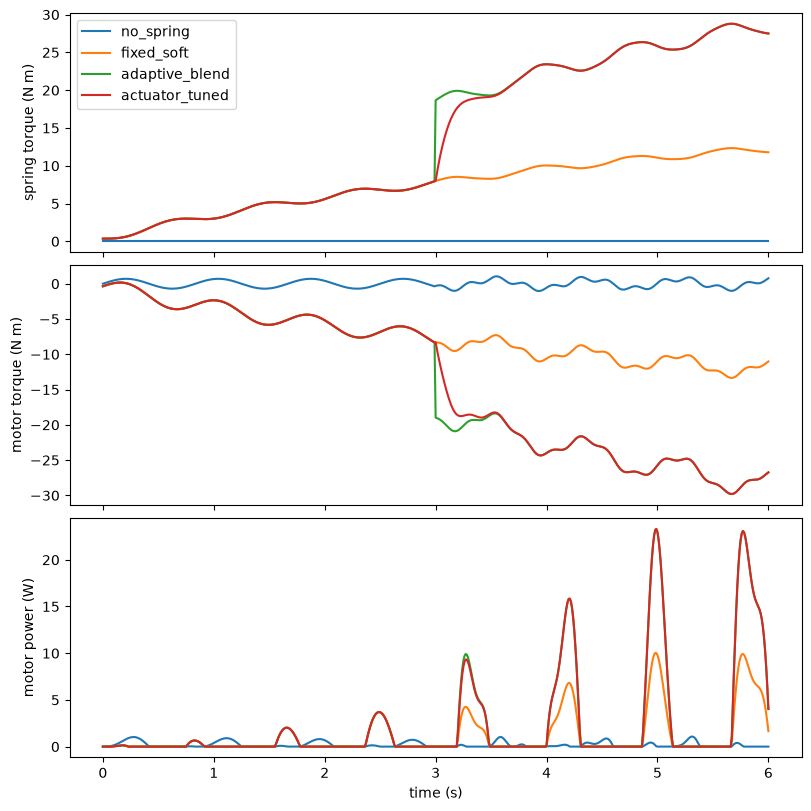

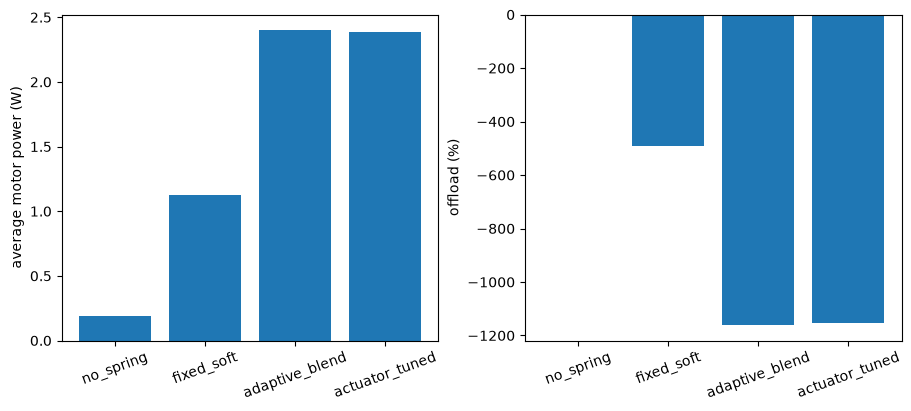

In [21]:
plot_joint_state(results)
plot_adaptive_state(results)
plot_torques_and_power(results)
plot_energy_comparison(energy);